In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
gowalla_norm = json.load(open("table5_eval_results_gowalla.json"))
yelp_norm    = json.load(open("table5_eval_results_yelp.json"))

gowalla_k = json.load(open("gowalla_results.json"))
yelp_k    = json.load(open("yelp_results.json"))

In [3]:
paper_gowalla_norm = {
    "l1": 0.1509,
    "l1_l": 0.1578,
    "l1_r": 0.1590,
    "l": 0.1589,
    "r": 0.1420,
    "sym": 0.1830
}

paper_yelp_norm = {
    "l1": 0.0600,
    "l1_l": 0.0587,
    "l1_r": 0.0573,
    "l": 0.0619,
    "r": 0.0521,
    "sym": 0.0649
}

paper_gowalla_k = [0.1556, 0.1777, 0.1823, 0.1830]
paper_yelp_k    = [0.0513, 0.0622, 0.0639, 0.0566]

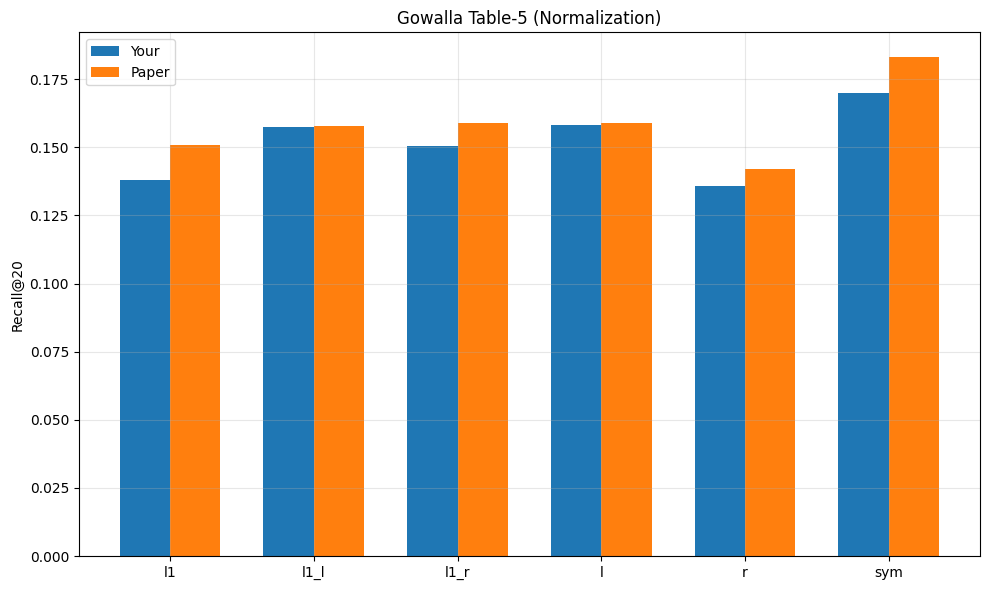

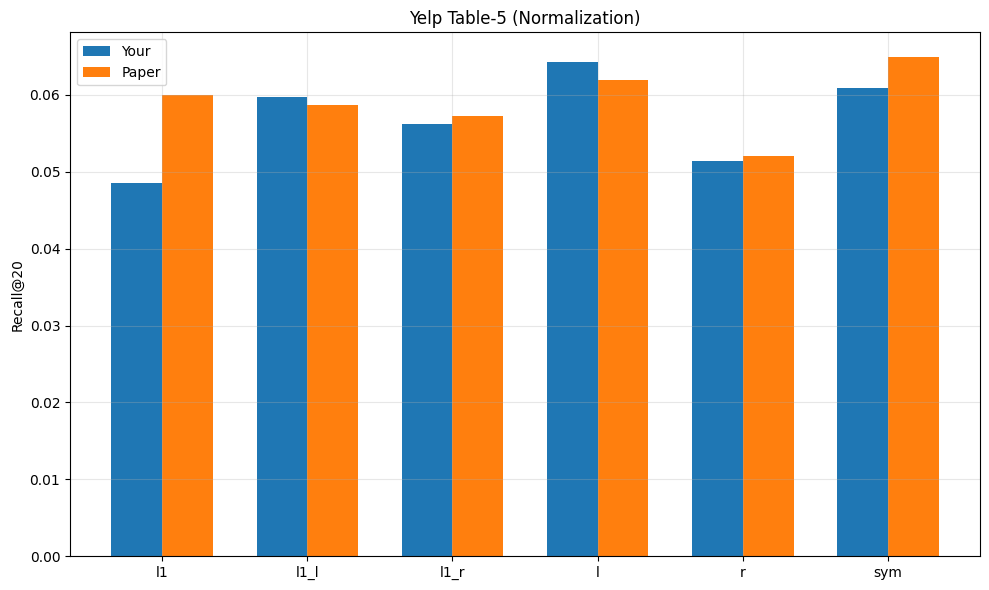

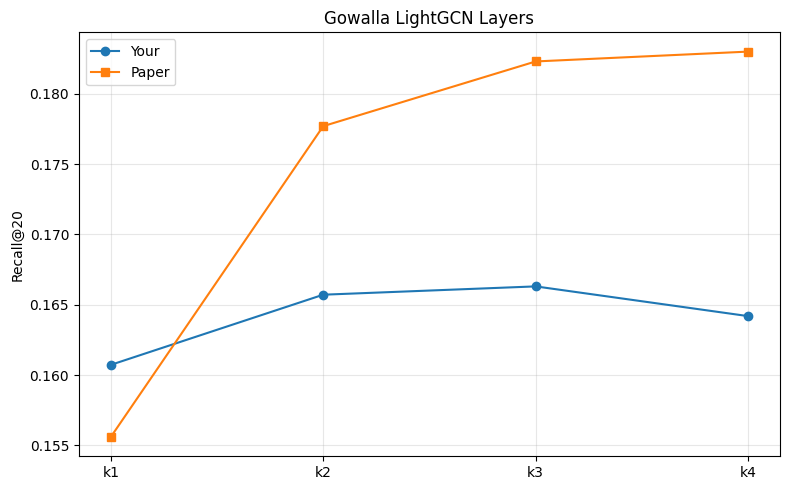

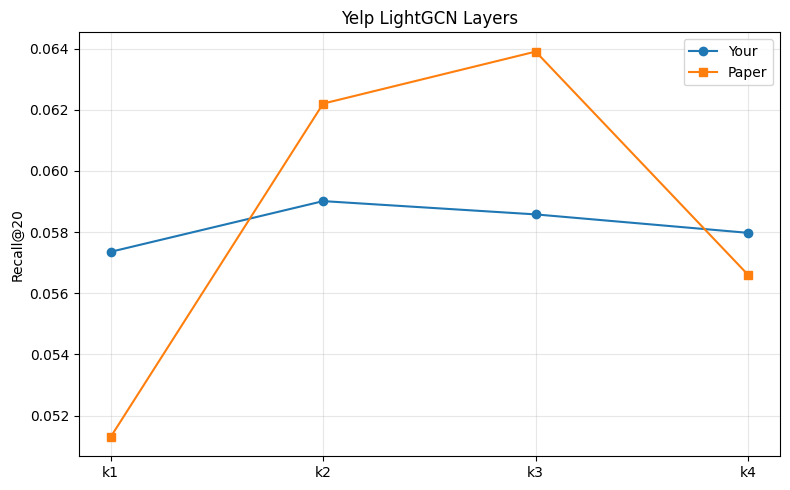

In [4]:
def plot_norm_comparison(your_data, paper_data, title):
    keys = ["l1", "l1_l", "l1_r", "l", "r", "sym"]

    your_vals = [your_data[k]["recall@20"] for k in keys]
    paper_vals = [paper_data[k] for k in keys]

    x = np.arange(len(keys))
    width = 0.35

    plt.figure(figsize=(10,6))
    plt.bar(x - width/2, your_vals, width, label="Your")
    plt.bar(x + width/2, paper_vals, width, label="Paper")

    plt.xticks(x, keys)
    plt.ylabel("Recall@20")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================
# 2. K-LAYER PLOT
# =========================
def plot_k_comparison(your_data, paper_data, title):
    k = ["k1", "k2", "k3", "k4"]

    your_vals = [your_data[x]["recall@20"] for x in k]

    x = np.arange(4)

    plt.figure(figsize=(8,5))
    plt.plot(x, your_vals, marker='o', label="Your")
    plt.plot(x, paper_data, marker='s', label="Paper")

    plt.xticks(x, k)
    plt.ylabel("Recall@20")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================
# RUN ALL PLOTS
# =========================

# TABLE-5
plot_norm_comparison(gowalla_norm, paper_gowalla_norm,
                     "Gowalla Table-5 (Normalization)")

plot_norm_comparison(yelp_norm, paper_yelp_norm,
                     "Yelp Table-5 (Normalization)")

# MAIN LIGHTGCN
plot_k_comparison(gowalla_k, paper_gowalla_k,
                  "Gowalla LightGCN Layers")

plot_k_comparison(yelp_k, paper_yelp_k,
                  "Yelp LightGCN Layers")

In [7]:
with open(r"F:\SEM-6\ELECTIVES\DEPARTMENT-ELECTIVES\Recommendation Systems\RS-Project\test\gowalla_results.json") as f:
    lightgcn = json.load(f)

with open(r"F:\SEM-6\ELECTIVES\DEPARTMENT-ELECTIVES\Recommendation Systems\RS-Project\test\single_results_gowalla.json") as f:
    single = json.load(f)

layers = [1, 2, 3, 4]
x = np.arange(len(layers))  # positions
width = 0.35               # bar width

In [ ]:
lgcn_recall = [lightgcn[f'k{i}']['recall@20'] for i in layers]
lgcn_ndcg   = [lightgcn[f'k{i}']['ndcg@20'] for i in layers]

single_recall = [single[f'k{i}']['recall@20'] for i in layers]
single_ndcg   = [single[f'k{i}']['ndcg@20'] for i in layers]

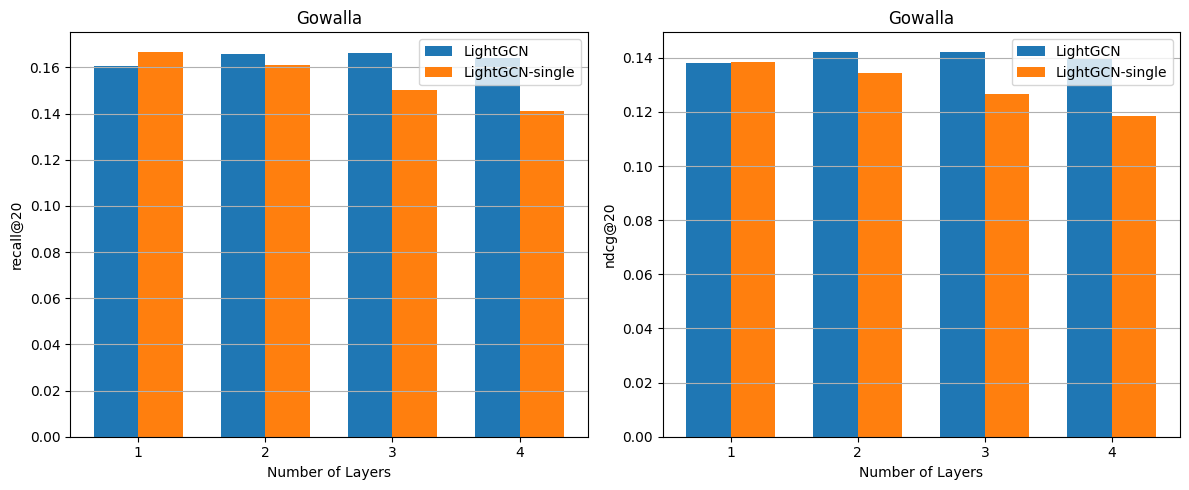

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Recall ----
axes[0].bar(x - width/2, lgcn_recall, width, label='LightGCN')
axes[0].bar(x + width/2, single_recall, width, label='LightGCN-single')

axes[0].set_title("Gowalla")
axes[0].set_xlabel("Number of Layers")
axes[0].set_ylabel("recall@20")
axes[0].set_xticks(x)
axes[0].set_xticklabels(layers)
axes[0].legend()
axes[0].grid(axis='y')

axes[1].bar(x - width/2, lgcn_ndcg, width, label='LightGCN')
axes[1].bar(x + width/2, single_ndcg, width, label='LightGCN-single')

axes[1].set_title("Gowalla")
axes[1].set_xlabel("Number of Layers")
axes[1].set_ylabel("ndcg@20")
axes[1].set_xticks(x)
axes[1].set_xticklabels(layers)
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig("gowalla_bar_comparison.png", dpi=300)
plt.show()